# Week 2 - Optimistic Initial Values and UCB Action Selection

This notebook extends the 10-armed bandit setup from Week 1 and compares two additional exploration strategies from Sutton and Barto: optimistic initial values and Upper-Confidence-Bound (UCB) action selection.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = next(
    path for path in [cwd, *cwd.parents] if (path / "src" / "bandits").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.bandits.agents import EpsilonGreedyAgent, UCBAgent
from src.bandits.experiments import run_multiple_agent_experiments
from src.utils.plotting import plot_average_reward, plot_optimal_action_percentage

## Context

Week 1 used epsilon-greedy exploration in the stationary 10-armed bandit problem. Week 2 adds two more exploration ideas:

- optimistic initial values
- UCB action selection

Both strategies use the same environment, but they encourage exploration in different ways.

## Tracking a Nonstationary Problem

A stationary bandit has fixed true action values during a run. A nonstationary bandit changes over time, so the agent must keep adapting.

Sample-average updates use a step size of `1 / N`, which becomes smaller as more data is collected. That is useful in stationary problems, but it can adapt too slowly in nonstationary settings. A constant step size gives more weight to recent rewards and is often better when the environment drifts.

This notebook keeps the stationary 10-armed bandit from Week 1 and treats the nonstationary case as a conceptual extension.

## Optimistic Initial Values

Optimistic initial values start every action-value estimate at a high number, such as Q<sub>0</sub> = 5. I used Q<sub>0</sub> = 5 here because it is clearly optimistic relative to the typical reward scale in this testbed, so the exploration effect is easy to see. Even a greedy agent then explores early because the first realistic rewards pull tried actions downward, leaving untried actions looking better.

The comparison here is:

- epsilon-greedy with `epsilon = 0.1`, Q<sub>0</sub> = 0
- optimistic greedy with `epsilon = 0`, Q<sub>0</sub> = 5

In [3]:
agent_configs_optimistic = {
    "Epsilon-greedy epsilon=0.1, Q₀=0": {
        "agent_class": EpsilonGreedyAgent,
        "agent_kwargs": {
            "epsilon": 0.1,
            "initial_value": 0.0,
        },
    },
    "Optimistic greedy epsilon=0, Q₀=5": {
        "agent_class": EpsilonGreedyAgent,
        "agent_kwargs": {
            "epsilon": 0.0,
            "initial_value": 5.0,
        },
    },
}

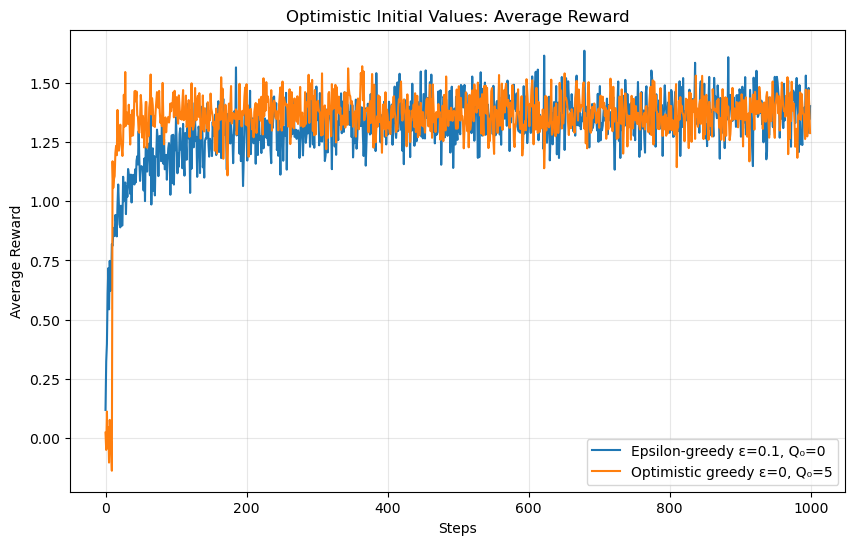

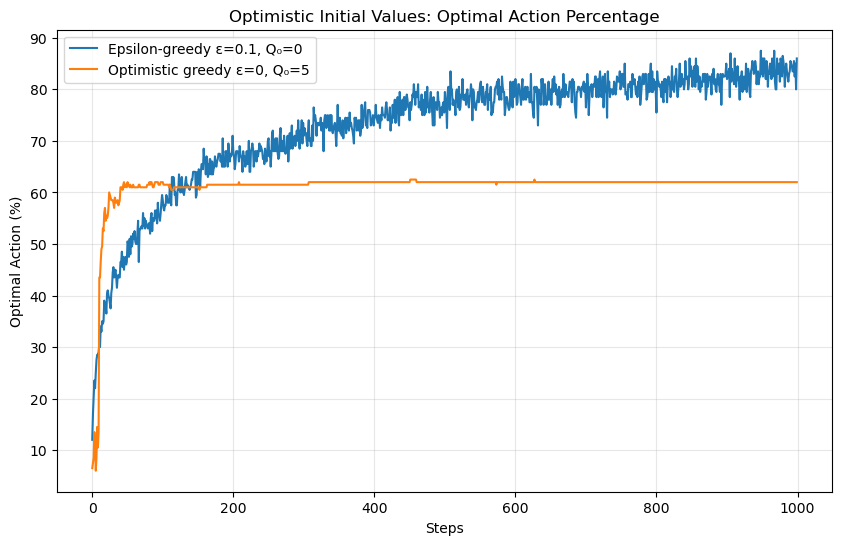

In [4]:
optimistic_results = run_multiple_agent_experiments(
    agent_configs=agent_configs_optimistic,
    n_runs=200,
    n_steps=1000,
    n_actions=10,
    seed=0,
)

plot_average_reward(
    optimistic_results,
    title="Optimistic Initial Values: Average Reward",
)
plot_optimal_action_percentage(
    optimistic_results,
    title="Optimistic Initial Values: Optimal Action Percentage",
)

In the curves, optimistic greedy usually explores hard at the beginning because every action starts out looking good. That often helps the optimal-action percentage rise quickly after the first few updates, but the average reward can be noisy early because the estimates are being corrected from an artificially high starting point.

The tradeoff is that this exploration is mostly front-loaded. Once the optimistic estimates have been pushed down, the method behaves much more like an ordinary greedy strategy and does not keep encouraging exploration later in the run.

## UCB Action Selection

UCB chooses actions by combining estimated value with an uncertainty bonus:

$$
A_t = \arg\max_a \left[ Q_t(a) + c \sqrt{\frac{\ln(t)}{N_t(a)}} \right]
$$

The constant `c` controls how strongly the agent favors uncertain actions. I used `c = 2` as a simple baseline that makes the uncertainty bonus visible without letting it dominate the value estimates for too long. Untried actions need special handling because `N_t(a) = 0`, so the implementation selects randomly among untried actions before applying the formula.

In [5]:
agent_configs_ucb = {
    "Epsilon-greedy epsilon=0.1": {
        "agent_class": EpsilonGreedyAgent,
        "agent_kwargs": {
            "epsilon": 0.1,
            "initial_value": 0.0,
        },
    },
    "UCB c=2": {
        "agent_class": UCBAgent,
        "agent_kwargs": {
            "c": 2.0,
            "initial_value": 0.0,
        },
    },
}

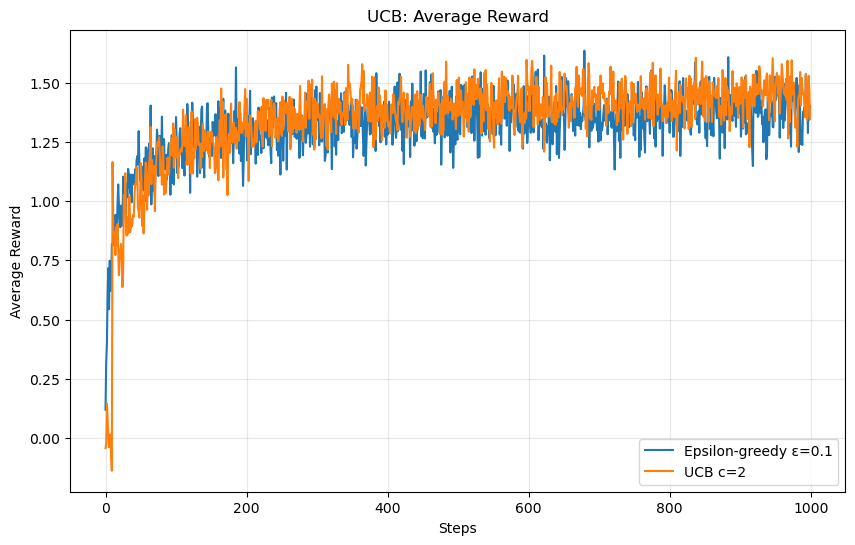

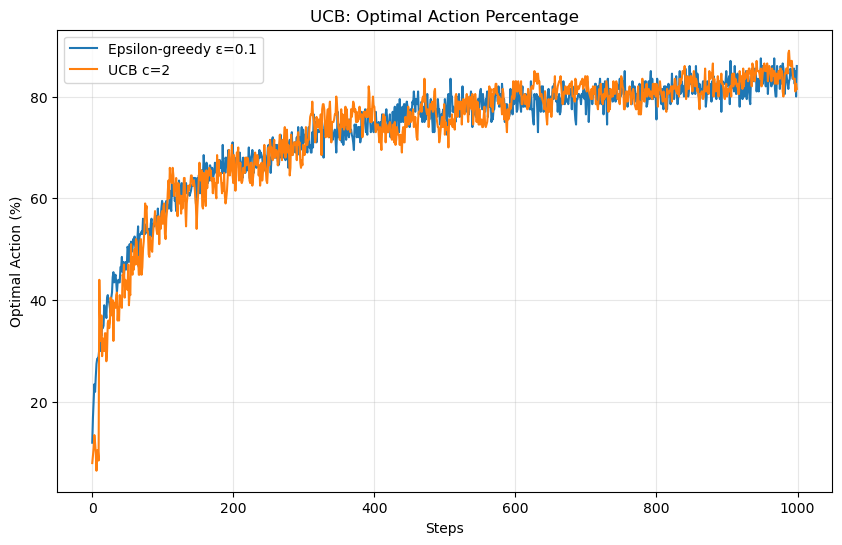

In [6]:
ucb_results = run_multiple_agent_experiments(
    agent_configs=agent_configs_ucb,
    n_runs=200,
    n_steps=1000,
    n_actions=10,
    seed=0,
)

plot_average_reward(
    ucb_results,
    title="UCB: Average Reward",
)
plot_optimal_action_percentage(
    ucb_results,
    title="UCB: Optimal Action Percentage",
)

In the plots, UCB usually looks more controlled than epsilon-greedy after the initial warm-up. Instead of spending exploration on random actions, it keeps revisiting actions that are still uncertain, which often leads to stronger average reward and a steadier rise in optimal-action selection.

That is the main advantage here: exploration depends on what the agent has learned so far rather than on uniform random action selection.

## Final Run and Saved Figures

After the smaller debug runs, the final figures use `n_runs = 2000` and save the Week 2 plots into `results/week_02/`.

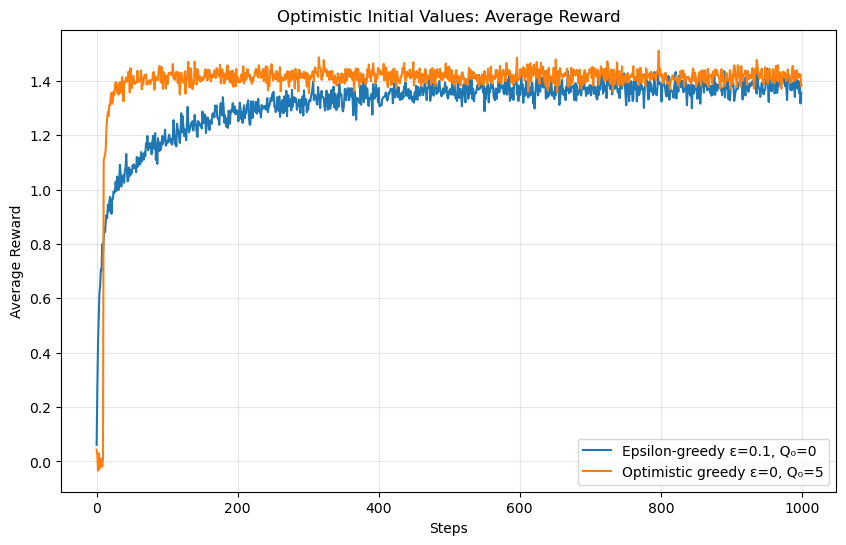

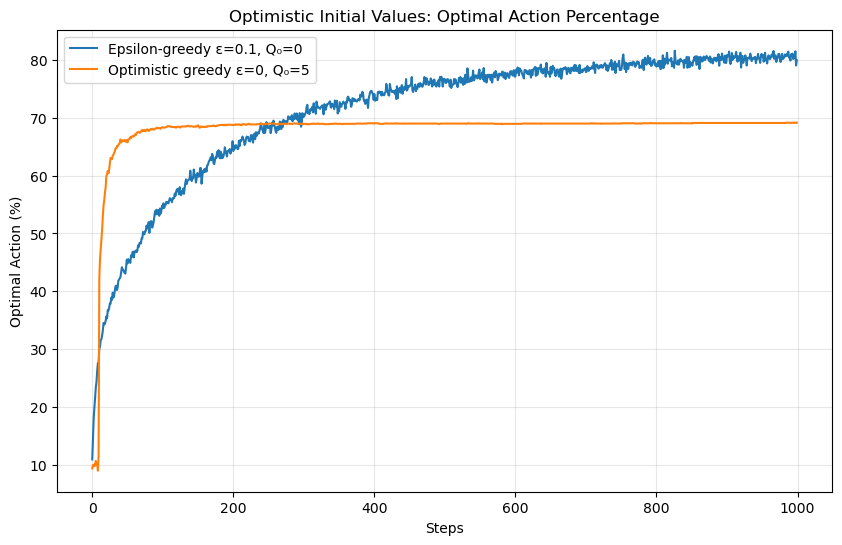

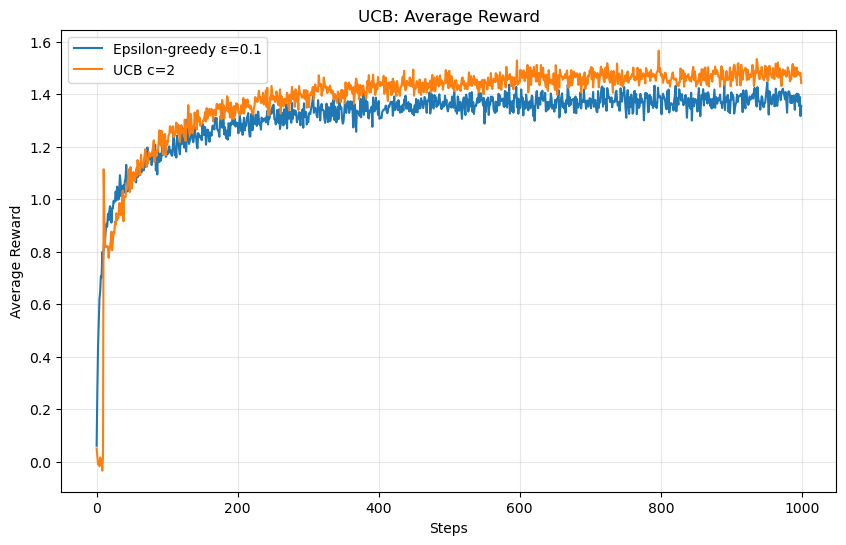

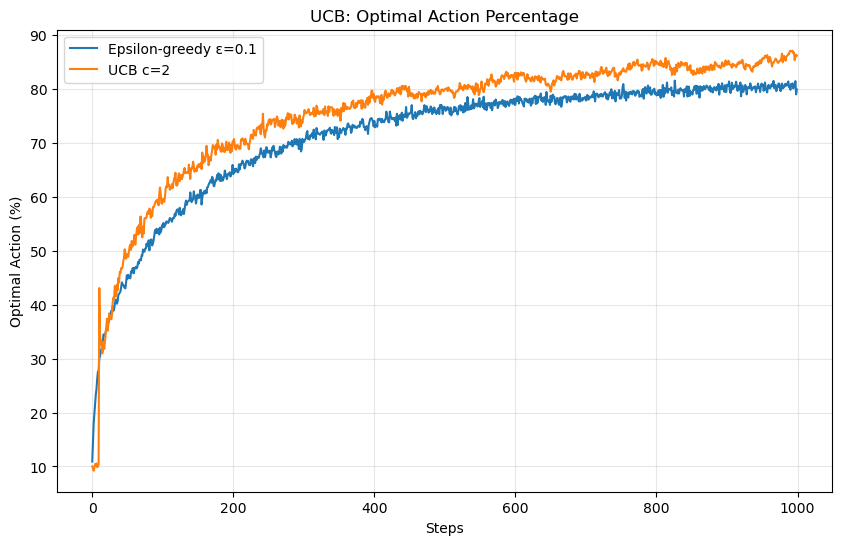

WindowsPath('D:/Machine_Learning_projects/RL_Projects/reinforcement-learning-series/results/week_02')

In [7]:
final_optimistic_results = run_multiple_agent_experiments(
    agent_configs=agent_configs_optimistic,
    n_runs=2000,
    n_steps=1000,
    n_actions=10,
    seed=1,
)

final_ucb_results = run_multiple_agent_experiments(
    agent_configs=agent_configs_ucb,
    n_runs=2000,
    n_steps=1000,
    n_actions=10,
    seed=1,
)

results_dir = project_root / "results" / "week_02"

plot_average_reward(
    final_optimistic_results,
    save_path=results_dir / "optimistic_initial_values_average_reward.png",
    title="Optimistic Initial Values: Average Reward",
)
plot_optimal_action_percentage(
    final_optimistic_results,
    save_path=results_dir / "optimistic_initial_values_optimal_action.png",
    title="Optimistic Initial Values: Optimal Action Percentage",
)
plot_average_reward(
    final_ucb_results,
    save_path=results_dir / "ucb_average_reward.png",
    title="UCB: Average Reward",
)
plot_optimal_action_percentage(
    final_ucb_results,
    save_path=results_dir / "ucb_optimal_action.png",
    title="UCB: Optimal Action Percentage",
)

results_dir

## Week 2 Takeaways

- Epsilon-greedy explores through randomness.
- Optimistic initial values explore through inflated starting estimates.
- UCB explores through uncertainty-aware action bonuses.

Optimistic initial values are simple and effective for early exploration, while UCB provides a more directed exploration signal throughout learning.